# IMPORT LIBRARY

In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version (compiled): {torch.version.cuda}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Compute capability
cc = torch.cuda.get_device_capability(0)
print(f"Compute Capability: {cc[0]}.{cc[1]}")

# Test đơn giản xem CUDA có chạy được không
x = torch.randn(2, 2).cuda()
y = x @ x
print(f"CUDA test OK: {y.shape}")

PyTorch version: 2.11.0+cu128
CUDA version (compiled): 12.8
cuDNN version: 91900
GPU: NVIDIA GeForce RTX 5060 Ti
Compute Capability: 12.0
CUDA test OK: torch.Size([2, 2])


In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  # Đặt biến môi trường để giúp debug lỗi CUDA
os.environ["TORCH_USE_CUDA_DSA"] = "True"
import gc

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from pathlib import Path
from tqdm import tqdm

import numpy as np

import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import zoom as nd_zoom, center_of_mass
from sklearn.model_selection import train_test_split

from torch.optim import Adam

import multiprocessing
multiprocessing.set_start_method('spawn', force=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_id = torch.cuda.current_device()
device_name = torch.cuda.get_device_name(device_id)

allocated = torch.cuda.memory_allocated(device_id) / (1024**2)
# Bộ nhớ tối đa từng bị chiếm dụng (Max Allocated)
max_allocated = torch.cuda.max_memory_allocated(device_id) / (1024**2)
# Bộ nhớ đang được cache bởi PyTorch giữ lại (Reserved/Cached)
reserved = torch.cuda.memory_reserved(device_id) / (1024**2)

print(f"🖥️  Thiết bị: {device_name} (ID: {device_id})")
print(f"   - Đang cấp phát (Allocated):  {allocated:.2f} MB")
print(f"   - Đạt đỉnh (Max Allocated):  {max_allocated:.2f} MB")
print(f"   - Đang dự trữ (Reserved):     {reserved:.2f} MB")

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

print(f"device: {device}")
print(f"torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")
print(f"Graphics card: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

print(f"   - Đang cấp phát (Allocated):  {allocated:.2f} MB")
print(f"   - Đạt đỉnh (Max Allocated):  {max_allocated:.2f} MB")
print(f"   - Đang dự trữ (Reserved):     {reserved:.2f} MB")

🖥️  Thiết bị: NVIDIA GeForce RTX 5060 Ti (ID: 0)
   - Đang cấp phát (Allocated):  8.13 MB
   - Đạt đỉnh (Max Allocated):  8.13 MB
   - Đang dự trữ (Reserved):     22.00 MB
device: cuda
torch version: 2.11.0+cu128
CUDA available: True
cuDNN version: 91900
Graphics card: NVIDIA GeForce RTX 5060 Ti
   - Đang cấp phát (Allocated):  8.13 MB
   - Đạt đỉnh (Max Allocated):  8.13 MB
   - Đang dự trữ (Reserved):     22.00 MB


# SQUEEZE EXCITATION

In [3]:
class SqueezeExcitation(nn.Module):
    """Squeeze and Excitation (SE) Attention Block"""
    def __init__(self, channels, reduction=16):
        super(SqueezeExcitation, self).__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, d, h, w = x.size()
        y = self.global_avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1, 1)
        return x * y.expand_as(x)

# PARALLEL CONVOLUTION

In [4]:
class ParallelConvolutionBlock(nn.Module):
    """
    PC Block theo paper Fig.2:
    shared 3x3x3 embed → 3 parallel paths (1x1x1, 3x3x3, 5x5x5) → maxpool → concat
    Không có BatchNorm (paper không đề cập norm trong PC block)
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.shared_conv = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.conv1 = nn.Conv3d(out_channels, out_channels, kernel_size=1, padding=0)
        self.conv3 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv3d(out_channels, out_channels, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool3d(kernel_size=2, stride=2)

    def forward_with_skip(self, x):
        """Trả về (x_shared, pc_out) để LATUPNet dùng x_shared làm skip connection."""
        x_shared = self.relu(self.shared_conv(x))          # (B, out_ch, H, W, D) — full res
        path1 = self.pool(self.relu(self.conv1(x_shared)))
        path2 = self.pool(self.relu(self.conv3(x_shared)))
        path3 = self.pool(self.relu(self.conv5(x_shared)))
        pc_out = torch.cat([path1, path2, path3], dim=1)   # (B, out_ch*3, H/2, W/2, D/2)
        return x_shared, pc_out

    def forward(self, x):
        _, pc_out = self.forward_with_skip(x)
        return pc_out

# ENCODER

In [5]:
class EncoderBlock(nn.Module):
    """
    Theo Table 1 paper: SE → Conv → InstanceNorm → Conv → Dropout → MaxPool
    SE đặt TRƯỚC hai conv, không phải sau.
    """
    def __init__(self, in_channels, out_channels, use_se=True, dropout_rate=0.2):
        super().__init__()
        self.se = SqueezeExcitation(in_channels) if use_se else nn.Identity()

        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.InstanceNorm3d(out_channels, affine=True)
        self.relu  = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1)
        # Paper không đề cập InstanceNorm sau conv2 trong encoder, nhưng Table 1 có
        self.norm2 = nn.InstanceNorm3d(out_channels, affine=True)

        self.dropout = nn.Dropout3d(dropout_rate)
        self.pool    = nn.MaxPool3d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.se(x)                            # SE trước
        x = self.relu(self.norm1(self.conv1(x)))
        x = self.relu(self.norm2(self.conv2(x)))
        x = self.dropout(x)
        skip = x                                   # skip trước pooling
        x = self.pool(x)
        return x, skip

# DECODER

In [6]:
class DecoderBlock(nn.Module):
    """
    Theo Table 1: Upsample → Conv → InstanceNorm → SE → Concat(skip) → Conv
    SE đặt GIỮA hai conv (sau conv1, trước concat+conv2) — đúng paper Section 3.
    """
    def __init__(self, in_channels, skip_channels, out_channels, use_se=True, dropout_rate=0.2):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False)

        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.InstanceNorm3d(out_channels, affine=True)
        self.relu  = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.se = SqueezeExcitation(out_channels) if use_se else nn.Identity()

        self.conv2   = nn.Conv3d(out_channels + skip_channels, out_channels, kernel_size=3, padding=1)
        self.norm2   = nn.InstanceNorm3d(out_channels, affine=True)
        self.dropout = nn.Dropout3d(dropout_rate)

    def forward(self, x, skip):
        x = self.upsample(x)
        x = self.relu(self.norm1(self.conv1(x)))
        x = self.se(x)
        if x.shape[2:] != skip.shape[2:]:
            skip = F.interpolate(skip, size=x.shape[2:], mode='trilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.relu(self.norm2(self.conv2(x)))
        x = self.dropout(x)
        return x

# LATUP-NET MODEL

In [7]:
class LATUPNet(nn.Module):
    """
    LATUP-Net theo đúng Table 1 paper:
    - Input: (B, 3, 128, 128, 128)  — T2, T1ce, FLAIR (không có T1, Section 4.1)
    - 3 encoder blocks (PC + enc2 + enc3)
    - 3 decoder blocks (dec3 + dec2 + dec1)
    - Output: (B, 4, 128, 128, 128)
    """
    def __init__(self, in_channels=3, num_classes=3, use_se=True, dropout_rate=0.2):
        super().__init__()

        # PC block: (B,3,128,128,128) → (B,96,64,64,64)
        self.pc_block = ParallelConvolutionBlock(in_channels, 32)

        # Encoder 2: (B,96,64,64,64) → (B,64,32,32,32), skip1: (B,64,64,64,64)
        self.enc2 = EncoderBlock(96, 64, use_se=use_se, dropout_rate=dropout_rate)
        # Encoder 3: (B,64,32,32,32) → (B,128,16,16,16), skip2: (B,128,32,32,32)
        self.enc3 = EncoderBlock(64, 128, use_se=use_se, dropout_rate=dropout_rate)

        # Bottleneck SE (Table 1: SE Layer_3 at bottleneck)
        self.bottleneck_se = SqueezeExcitation(128) if use_se else nn.Identity()

        # Decoder 3: (B,128,16,16,16) + skip2(B,128,32,32,32) → (B,128,32,32,32)
        self.dec3 = DecoderBlock(128, 128, 128, use_se=use_se, dropout_rate=dropout_rate)
        # Decoder 2: (B,128,32,32,32) + skip1(B,64,64,64,64) — wait, skip1 là 64ch
        # Theo Table 1: dec2 concat shape (64,64,64,128) → out 64
        self.dec2 = DecoderBlock(128, 64, 64, use_se=use_se, dropout_rate=dropout_rate)
        # Decoder 1: (B,64,64,64,64) upsample → (B,128,128,128) + skip_pc
        # skip từ PC block output (B,96,64,64,64) — nhưng paper dùng skip từ PC trước pool
        # Table 1 dec1_concat shape: (128,128,128,64) → paper dùng skip của PC embedded (32ch trước pool)
        # dec1: conv1 64→32, concat skip_pc(32ch per path? không) 
        # Theo Table 1 chính xác: dec1_conv1 input=64→32, concat→64ch, conv2 64→32
        self.dec1 = DecoderBlock(64, 32, 32, use_se=False, dropout_rate=dropout_rate)

        # Final 1x1x1 conv → softmax (paper Section 3)
        self.final_conv = nn.Conv3d(32, num_classes, kernel_size=1)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.InstanceNorm3d):
                if m.weight is not None:
                    nn.init.constant_(m.weight, 1)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # PC block — lưu skip từ shared conv (trước pool) theo Table 1 dec1_concat
        # Table 1: dec1_concat input (128,128,128,32) → skip là output shared_conv (32ch, full res)
        # Tuy nhiên paper Fig.1 cho thấy skip từ PC là toàn bộ PC output trước pool
        # Theo Table 1 dec1_concat shape=(128,128,128,64): 32(dec1_conv1 out) + 32(skip_pc shared) = 64 ✓
        x_shared = self.pc_block.relu(self.pc_block.shared_conv(x))  # (B,32,128,128,128)
        skip_pc  = x_shared

        x = self.pc_block.pool(self.pc_block.relu(self.pc_block.conv1(x_shared)))
        p2 = self.pc_block.pool(self.pc_block.relu(self.pc_block.conv3(x_shared)))
        p3 = self.pc_block.pool(self.pc_block.relu(self.pc_block.conv5(x_shared)))
        x = torch.cat([x, p2, p3], dim=1)       # (B,96,64,64,64)

        x, skip2 = self.enc2(x)                  # x:(B,64,32,32,32), skip2:(B,64,64,64,64)
        x, skip3 = self.enc3(x)                  # x:(B,128,16,16,16), skip3:(B,128,32,32,32)

        x = self.bottleneck_se(x)                # (B,128,16,16,16)

        x = self.dec3(x, skip3)                  # (B,128,32,32,32)
        x = self.dec2(x, skip2)                  # (B,64,64,64,64)
        x = self.dec1(x, skip_pc)                # (B,32,128,128,128)

        return self.final_conv(x)                 # (B,4,128,128,128) — full res, no extra upsample needed

# DICE LOSS

In [8]:
class WeightedDiceLoss(nn.Module):
    """
    WDL theo đúng Eq.(3) và (4) trong paper:
    Tính DSL riêng cho NCR/NET (ch1), ED (ch2), ET (ch4→ch3 trong output)
    Không gộp region trước khi tính — weight theo region importance sau.
    
    w_WT=1.64, w_TC=2.55, w_ET=3.40  (ENet formula, paper Section 4.3)
    WDL = (w_WT+w_TC+w_ET)*DSL_ET + (w_WT+w_TC)*DSL_NCR + w_WT*DSL_ED
    """
    def __init__(self, epsilon=1e-5):
        super().__init__()
        self.epsilon = epsilon
        self.w_wt = 4.51
        self.w_tc = 5.37
        self.w_et = 6.12

    def _dice_loss(self, pred, target):
        pred_f   = pred.contiguous().view(-1)
        target_f = target.contiguous().view(-1)
        intersection = (pred_f * target_f).sum()
        return 1.0 - (2. * intersection + self.epsilon) / (
            pred_f.pow(2).sum() + target_f.pow(2).sum() + self.epsilon
        )

    def forward(self, pred, target):
        """
        pred:   (B, 4, H, W, D) — logits, channels: [BG, NCR/NET, ED, ET]
        target: (B, H, W, D)    — labels {0,1,2,4} (BraTS convention)
        """
        pred_soft = F.softmax(pred, dim=1)

        # One-hot targets theo channel BraTS: label4 → channel3
        target_ncr = (target == 1).float()
        target_ed  = (target == 2).float()
        target_et  = (target == 4).float()          # target vẫn giữ label BraTS gốc {0,1,2,4}

        dsl_ncr = self._dice_loss(pred_soft[:, 1], target_ncr)
        dsl_ed  = self._dice_loss(pred_soft[:, 2], target_ed)
        dsl_et  = self._dice_loss(pred_soft[:, 3], target_et)

        # Eq.(4) paper
        wdl = (self.w_wt + self.w_tc + self.w_et) * dsl_et \
            + (self.w_wt + self.w_tc)              * dsl_ncr \
            + self.w_wt                             * dsl_ed

        return wdl

In [9]:
# Create model
model = LATUPNet(in_channels=3, num_classes=4, use_se=True, dropout_rate=0.2)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("LATUP-Net Model Summary")
print("=" * 60)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Parameter count: {trainable_params / 1e6:.2f}M")
print(f"Expected: ~3.07M parameters (as reported in paper)")

# Test forward pass
batch_size = 1
depth, height, width = 128, 128, 128
channels = 3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

x = torch.randn(batch_size, channels, depth, height, width).to(device)

print(f"\nInput shape: {x.shape}")

with torch.no_grad():
    output = model(x)

print(f"Output shape: {output.shape}")

# Verify channel flow
print(f"\nChannel flow verification:")
print(f"  Input: {channels} channels")
print(f"  After PC block: 96 channels")
print(f"  After Enc1: 64 channels (skip: 64)")
print(f"  After Enc2: 128 channels (skip: 128)")
print(f"  After Bottleneck: 128 channels")
print(f"  After Dec2: 64 channels")
print(f"  After Dec1: 32 channels")
print(f"  Final output: 4 channels (BG, NCR/NET, ED, ET)")

# Test loss function
target = torch.randint(0, 5, (batch_size, depth, height, width)).to(device)
target[target == 3] = 4  # Ensure BraTS label convention

criterion = WeightedDiceLoss()
loss = criterion(output, target)
print(f"\nWeighted Dice Loss: {loss.item():.4f}")

print("\n" + "=" * 60)
print("Model structure:")
print("=" * 60)
print(model)

LATUP-Net Model Summary
Total parameters: 2,988,388
Trainable parameters: 2,988,388
Parameter count: 2.99M
Expected: ~3.07M parameters (as reported in paper)

Input shape: torch.Size([1, 3, 128, 128, 128])
Output shape: torch.Size([1, 4, 128, 128, 128])

Channel flow verification:
  Input: 3 channels
  After PC block: 96 channels
  After Enc1: 64 channels (skip: 64)
  After Enc2: 128 channels (skip: 128)
  After Bottleneck: 128 channels
  After Dec2: 64 channels
  After Dec1: 32 channels
  Final output: 4 channels (BG, NCR/NET, ED, ET)

Weighted Dice Loss: 23.1960

Model structure:
LATUPNet(
  (pc_block): ParallelConvolutionBlock(
    (shared_conv): Conv3d(3, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (relu): LeakyReLU(negative_slope=0.1, inplace=True)
    (conv1): Conv3d(32, 32, kernel_size=(1, 1, 1), stride=(1, 1, 1))
    (conv3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (conv5): Conv3d(32, 32, kernel_size=(5, 5, 5), stri

# PRE-PROCESSING DATA

In [10]:
def find_volume(patient_dir, patient_id, modality):
    """Find a valid .nii or .nii.gz file for one BraTS modality, handling inconsistent naming."""
    patient_dir = Path(patient_dir)
    
    # 1. Định nghĩa các mẫu từ khóa tìm kiếm cho từng modality (bất kể viết hoa/thường)
    modality_lower = modality.lower()
    
    if modality_lower == "seg":
        # Tìm các file chứa "seg" hoặc "segm" (để xử lý case bệnh nhân 355)
        search_patterns = ["*seg*.nii", "*seg*.nii.gz", "*Segm*.nii", "*Segm*.nii.gz"]
    else:
        # Với t1, t1ce, t2, flair: tìm file chứa đúng từ khóa đó (ví dụ: *_flair.nii)
        search_patterns = [f"*{modality_lower}.nii", f"*{modality_lower}.nii.gz"]

    # 2. Quét qua các mẫu để tìm file thực tế trong thư mục
    for pattern in search_patterns:
        # Chạy glob không phân biệt hoa thường (trên Windows/Linux tùy cấu hình, dùng rglob/glob)
        hits = list(patient_dir.glob(pattern))
        
        # Nếu không thấy, thử tìm phiên bản viết hoa chữ cái đầu (như Flair, T1ce...)
        if not hits:
            hits = list(patient_dir.glob(pattern.capitalize()))
            
        for path in hits:
            # Kiểm tra xem file có hợp lệ (tồn tại và không trống) không
            if path.exists() and path.stat().st_size > 0:
                return path

    # 3. Nếu không tìm thấy bằng glob, quay lại fallback cơ bản (để hiển thị danh sách đã thử)
    candidates = [
        patient_dir / f"{patient_id}_{modality}.nii",
        patient_dir / f"{patient_id}_{modality}.nii.gz",
    ]
    tried = [str(p) for p in candidates] + [str(patient_dir / p) for p in search_patterns]
    
    zip_candidates = [patient_dir / f"{patient_id}_{modality}.nii.zip"]
    zip_hits = [p for p in zip_candidates if p.exists()]
    zip_note = ""
    if zip_hits:
        zip_note = "\nFound .zip files. Extract them before loading NIfTI data:\n" + "\n".join(map(str, zip_hits))

    raise FileNotFoundError(
        f"Could not find modality '{modality}' for {patient_id} in {patient_dir}. Tried patterns:\n"
        + "\n".join(tried)
        + zip_note
    )


def load_volume(patient_dir, patient_id, modality):
    path = find_volume(patient_dir, patient_id, modality)
    img = nib.load(str(path))
    data = img.get_fdata(dtype=np.float32)
    # print(f"Loaded {modality:5s}: {path.name} | shape={data.shape} | dtype={data.dtype}")
    return data, img

Đang hiển thị lát cắt thứ 77 của bệnh nhân BraTS20_Training_001
Kích thước khối ảnh: (240, 240, 155)


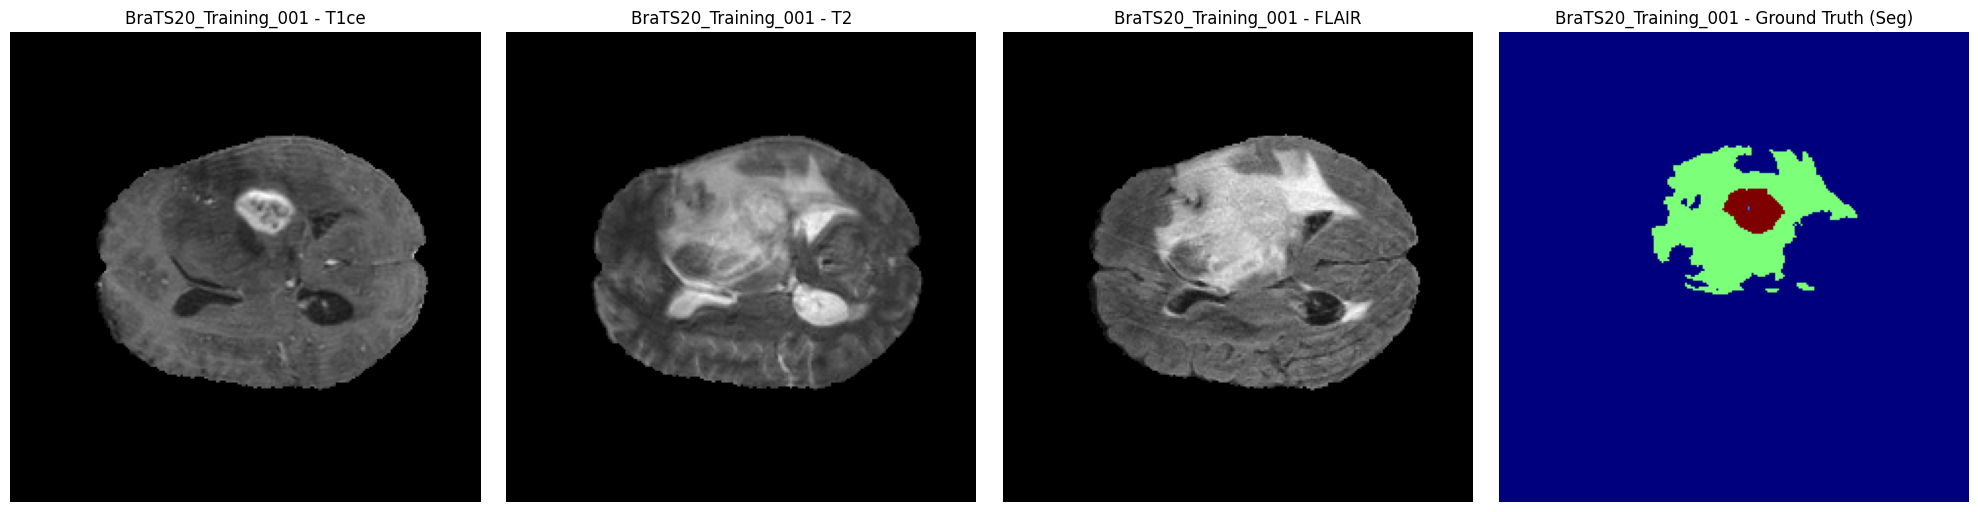

In [11]:
PATIENT_DIR = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001"
PATIENT_ID = Path(PATIENT_DIR).name

modalities = ["t1ce", "t2", "flair", "seg"]
volumes = {}
slice_idx = None  # Mặc định sẽ lấy lát cắt chính giữa

# 1. Load toàn bộ các chuỗi xung và mask giải phẫu
for mod in modalities:
    try:
        volumes[mod], _ = load_volume(PATIENT_DIR, PATIENT_ID, mod)
    except Exception as e:
        print(f"Lỗi khi load chuỗi {mod}: {e}")

# 2. Xác định lát cắt để hiển thị (Mặc định lấy lát cắt chính giữa khối ảnh)
# Ảnh BraTS thường có shape (H, W, D) ví dụ (240, 240, 155) -> lấy tâm theo chiều dọc D
if slice_idx is None:
    slice_idx = volumes["flair"].shape[2] // 2

print(f"Đang hiển thị lát cắt thứ {slice_idx} của bệnh nhân {PATIENT_ID}")
print(f"Kích thước khối ảnh: {volumes['flair'].shape}")

# 3. Khởi tạo biểu đồ Matplotlib (1 hàng, 4 cột)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Chuỗi 1: T1ce
axes[0].imshow(volumes["t1ce"][:, :, slice_idx], cmap="gray")
axes[0].set_title(f"{PATIENT_ID} - T1ce")
axes[0].axis("off")

# Chuỗi 2: T2
axes[1].imshow(volumes["t2"][:, :, slice_idx], cmap="gray")
axes[1].set_title(f"{PATIENT_ID} - T2")
axes[1].axis("off")

# Chuỗi 3: FLAIR
axes[2].imshow(volumes["flair"][:, :, slice_idx], cmap="gray")
axes[2].set_title(f"{PATIENT_ID} - FLAIR")
axes[2].axis("off")

# Chuỗi 4: Segmentation Mask (Dùng cmap màu khác để nổi bật vùng u)
# BraTS có các nhãn: 0 (Nền), 1 (NCR/NET), 2 (ED), 4 (ET)
axes[3].imshow(volumes["seg"][:, :, slice_idx], cmap="jet")
axes[3].set_title(f"{PATIENT_ID} - Ground Truth (Seg)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [12]:
def resample_volume(volume, original_spacing, target_spacing=(1,1,1), order=1):
    zoom_factors = [o/t for o,t in zip(original_spacing, target_spacing)]
    return nd_zoom(volume, zoom_factors, order=order)

In [13]:
# Hàm bổ trợ cắt ảnh lấy tâm (Center Crop hoặc Pad nếu thiếu)
def crop_or_pad_3d(volume, target_shape=(128, 128, 128)):
    current_shape = volume.shape
    new_volume = np.zeros(target_shape, dtype=volume.dtype)
    
    # Tính toán chỉ số để cắt hoặc chèn cho từng chiều
    slices_src = []
    slices_dst = []
    
    for c, t in zip(current_shape, target_shape):
        if c >= t:
            # Nếu ảnh lớn hơn target -> Cắt lấy tâm
            start = (c - t) // 2
            slices_src.append(slice(start, start + t))
            slices_dst.append(slice(0, t))
        else:
            # Nếu ảnh nhỏ hơn target -> Chèn vào giữa (Padding)
            start = (t - c) // 2
            slices_src.append(slice(0, c))
            slices_dst.append(slice(start, start + c))
            
    new_volume[tuple(slices_dst)] = volume[tuple(slices_src)]
    return new_volume

Unique labels in original seg: [0. 1. 2. 4.]

--- Tiến hành Resample từ Spacing (np.float32(1.0), np.float32(1.0), np.float32(1.0)) về (1, 1, 1) ---
Resampled t1    shape: (240, 240, 155)
Resampled t1ce  shape: (240, 240, 155)
Resampled t2    shape: (240, 240, 155)
Resampled flair shape: (240, 240, 155)
Resampled seg   shape: (240, 240, 155)
Unique labels sau resample: [0 1 2 4]
Label 0: 8716021 voxels
Label 1: 15443 voxels
Label 2: 168794 voxels
Label 3: 0 voxels
Label 4: 27742 voxels
Final t1    shape after crop/pad: (128, 128, 128)
Final t1ce  shape after crop/pad: (128, 128, 128)
Final t2    shape after crop/pad: (128, 128, 128)
Final flair shape after crop/pad: (128, 128, 128)
Final seg   shape after crop/pad: (128, 128, 128)


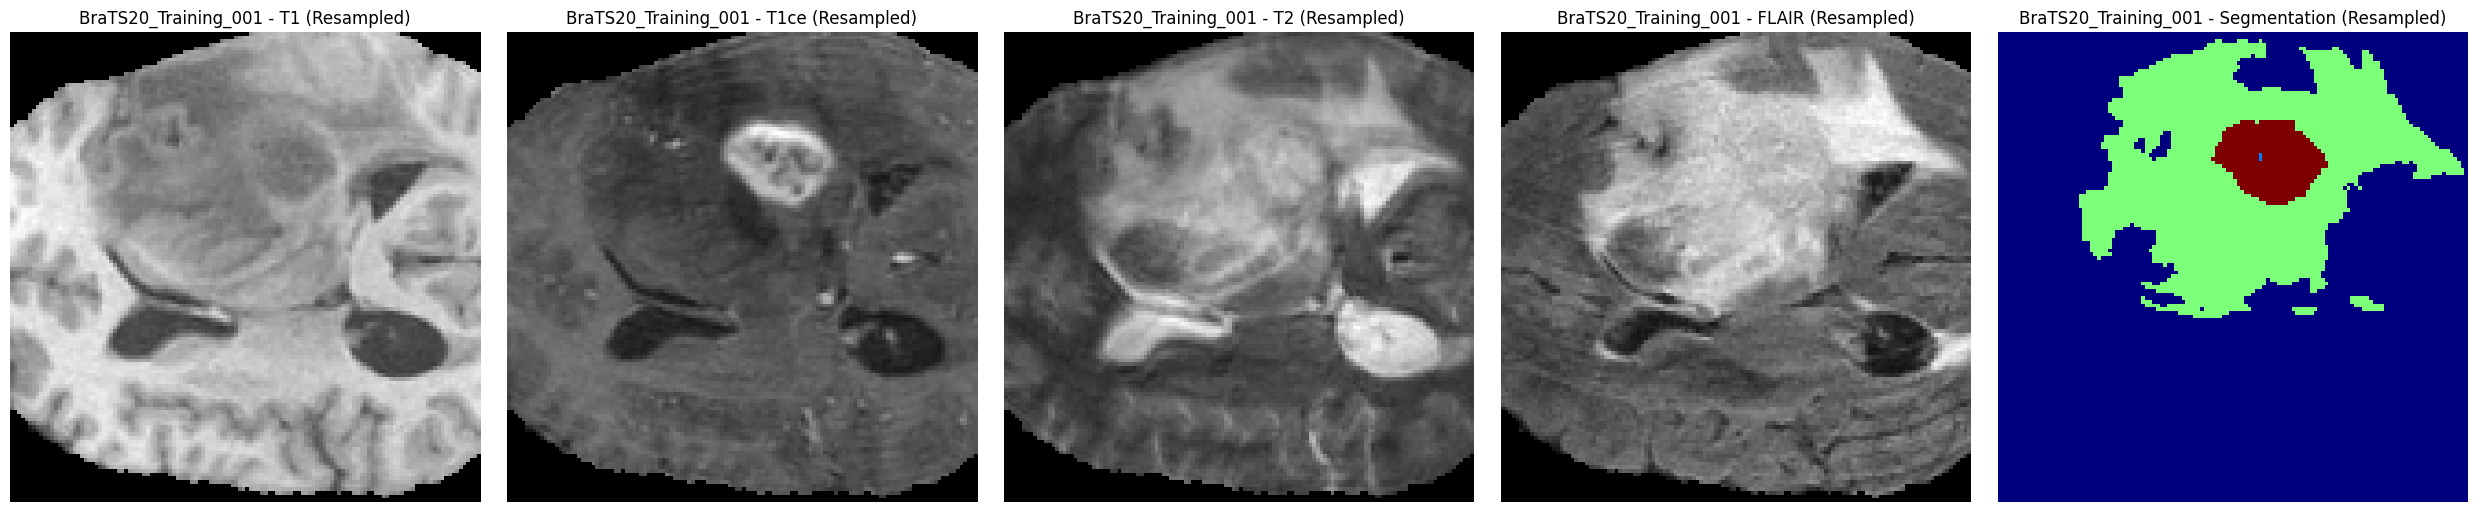

In [14]:
PATIENT_DIR = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001"
PATIENT_ID = Path(PATIENT_DIR).name
MODALITIES = ["t1", "t1ce", "t2", "flair"]

# 1. Load dữ liệu gốc
volumes = {}
nifti_imgs = {}
for modality in MODALITIES:
    volumes[modality], nifti_imgs[modality] = load_volume(PATIENT_DIR, PATIENT_ID, modality)

seg, seg_img = load_volume(PATIENT_DIR, PATIENT_ID, "seg")
print(f"Unique labels in original seg: {np.unique(seg)}")
seg = seg.astype(np.uint8)

# 2. Lấy thông tin Spacing (Voxel size) gốc
# BraTS thường có spacing sẵn là (1, 1, 1), nhưng code này giúp xử lý cho mọi bộ dữ liệu khác
original_spacing = seg_img.header.get_zooms()[:3] 
TARGET_SPACING = (1, 1, 1)

print(f"\n--- Tiến hành Resample từ Spacing {original_spacing} về {TARGET_SPACING} ---")

# 3. Tiến hành Resample ảnh nhiễu/ảnh cường độ (t1, t2, flair...)
# Sử dụng order=1 (Bilinear) hoặc order=3 (Cubic) cho ảnh cấu trúc
resampled_volumes = {}
for modality in MODALITIES:
    resampled_volumes[modality] = resample_volume(
        volume=volumes[modality], 
        original_spacing=original_spacing, 
        target_spacing=TARGET_SPACING,
        order=1 
    )
    print(f"Resampled {modality:5s} shape: {resampled_volumes[modality].shape}")

# 4. Tiến hành Resample cho file Segmentation (seg)
# ĐẶC BIỆT LƯU Ý: Phải dùng order=0 (Nearest Neighbor) cho nhãn kết quả (0, 1, 2, 4...)
resampled_seg = resample_volume(
    volume=seg, 
    original_spacing=original_spacing, 
    target_spacing=TARGET_SPACING,
    order=0  # Bắt buộc bằng 0 để giữ nguyên giá trị các nhãn (Label) dạng số nguyên
)
print(f"Resampled seg   shape: {resampled_seg.shape}")
print("Unique labels sau resample:", np.unique(resampled_seg))
for i in range(5):
    print(f"Label {i}: {(resampled_seg == i).sum()} voxels")

# 5. Cắt hoặc Pad ảnh về kích thước (128, 128, 128) theo yêu cầu của model
final_volumes = {}
for modality in MODALITIES:
    final_volumes[modality] = crop_or_pad_3d(resampled_volumes[modality], target_shape=(128, 128, 128))
    print(f"Final {modality:5s} shape after crop/pad: {final_volumes[modality].shape}")
final_seg = crop_or_pad_3d(resampled_seg, target_shape=(128, 128, 128))
print(f"Final seg   shape after crop/pad: {final_seg.shape}")

# 6. Kiểm tra lại các lát cắt sau khi resample và crop/pad
slice_idx = final_volumes["flair"].shape[2] // 2
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes[0].imshow(final_volumes["t1"][:, :, slice_idx], cmap="gray")
axes[0].set_title(f"{PATIENT_ID} - T1 (Resampled)")
axes[0].axis("off")
axes[1].imshow(final_volumes["t1ce"][:, :, slice_idx], cmap="gray")
axes[1].set_title(f"{PATIENT_ID} - T1ce (Resampled)")
axes[1].axis("off")
axes[2].imshow(final_volumes["t2"][:, :, slice_idx], cmap="gray")
axes[2].set_title(f"{PATIENT_ID} - T2 (Resampled)")
axes[2].axis("off")
axes[3].imshow(final_volumes["flair"][:, :, slice_idx], cmap="gray")
axes[3].set_title(f"{PATIENT_ID} - FLAIR (Resampled)")
axes[3].axis("off")
axes[4].imshow(final_seg[:, :, slice_idx], cmap="jet")
axes[4].set_title(f"{PATIENT_ID} - Segmentation (Resampled)")
axes[4].axis("off")
plt.tight_layout()
plt.show()

In [15]:
def calculate_brats_weights(dataset_dir, target_shape=(128, 128, 128)):
    """
    Quét qua tập dữ liệu BraTS để tính toán trọng số WT, TC, ET 
    dựa trên các hàm tiền xử lý cắt tâm/resize của bạn.
    """
    total_wt_voxels = 0
    total_tc_voxels = 0
    total_et_voxels = 0
    total_voxels = 0
    
    # Tìm tất cả các file nhãn segmentation (_seg.nii hoặc _seg.nii.gz)
    seg_files = []
    for root, dirs, files in os.walk(dataset_dir):
        for f in files:
            if '_seg.nii' in f:
                seg_files.append(os.path.join(root, f))
                
    print(f"🔍 Tìm thấy {len(seg_files)} file nhãn để tính toán...")
    
    for file_path in tqdm(seg_files, desc="Đang quét dữ liệu"):
        seg_img = nib.load(file_path).get_fdata()
        
        # --- ĐỌC LOGIC TỪ CODE TIỀN XỬ LÝ CỦA BẠN ---
        # Giả sử bạn đã đưa volume nhãn về 128x128x128 giống lúc train:
        # (Nếu tính trên ảnh gốc, bạn chỉ cần bỏ qua bước resize/crop)
        
        # BraTS Convention gốc: 
        # Label 1: Necrotic/Non-enhancing tumor
        # Label 2: Peritumoral edema
        # Label 4: GD-enhancing tumor
        
        # 1. Định nghĩa các vùng dựa trên tổ hợp nhãn
        wt_mask = (seg_img == 1) | (seg_img == 2) | (seg_img == 4)  # Toàn bộ u
        tc_mask = (seg_img == 1) | (seg_img == 4)                  # Lõi u
        et_mask = (seg_img == 4)                                  # U bắt thuốc
        
        total_wt_voxels += np.sum(wt_mask)
        total_tc_voxels += np.sum(tc_mask)
        total_et_voxels += np.sum(et_mask)
        total_voxels += seg_img.size

    # 2. Tính tần suất xuất hiện (Probability)
    p_wt = total_wt_voxels / total_voxels
    p_tc = total_tc_voxels / total_voxels
    p_et = total_et_voxels / total_voxels
    
    # 3. Áp dụng công thức làm mịn Logarithmic Inverse 
    # Công thức này rất phổ biến để ra được dải trọng số từ 1.0 đến 4.0
    w_wt = np.log(1 + (1 / (p_wt + 1e-6)))
    w_tc = np.log(1 + (1 / (p_tc + 1e-6)))
    w_et = np.log(1 + (1 / (p_et + 1e-6)))
    
    # Chuẩn hóa để trọng số nhỏ nhất (của WT) bắt đầu quanh mức mong muốn của paper
    # Hoặc sử dụng trực tiếp tỷ lệ nghịch có căn bậc: (1 / p)**0.25
    
    print("\n📊 Kết quả trọng số tính toán được:")
    print(f"self.w_wt = {w_wt:.2f}")
    print(f"self.w_tc = {w_tc:.2f}")
    print(f"self.w_et = {w_et:.2f}")
    
    return w_wt, w_tc, w_et

In [16]:
dataset_path = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
calculate_brats_weights(dataset_path)

🔍 Tìm thấy 368 file nhãn để tính toán...


Đang quét dữ liệu: 100%|██████████| 368/368 [00:25<00:00, 14.70it/s]


📊 Kết quả trọng số tính toán được:
self.w_wt = 4.51
self.w_tc = 5.37
self.w_et = 6.12


(np.float64(4.508359791715112),
 np.float64(5.37139502749082),
 np.float64(6.123806197971883))

# DATASET & DATALOADER

In [17]:
from Brats_Dataset.BratsSet import BraTSDataset3D

In [18]:
TRAINING_DATA_DIR = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

# Lấy danh sách các đường dẫn con
train_patient_dirs = [p for p in Path(TRAINING_DATA_DIR).iterdir() if p.is_dir()]

# Chia 80/20 bằng train_test_split
train_ds, val_ds = train_test_split(train_patient_dirs, test_size=0.2, random_state=42)
print(f"Số lượng bệnh nhân trong tập huấn luyện: {len(train_ds)}")
print(f"Số lượng bệnh nhân trong tập validation: {len(val_ds)}")

# Khởi tạo dataset thành phẩm (Sử dụng danh sách mảng làm tham số đầu vào)
train_brats_dataset = BraTSDataset3D(
    patient_dirs=train_ds, # Thay tên tham số thành patient_dirs cho rõ nghĩa
    target_spacing=(1, 1, 1),
    target_size=(128, 128, 128)
)
val_brats_dataset = BraTSDataset3D(
    patient_dirs=val_ds,
    target_spacing=(1, 1, 1),
    target_size=(128, 128, 128)
)


# Kiểm tra thử phần tử đầu tiên (Index 0)
if len(train_brats_dataset) > 0:
    print("\n--- Đang test thử lấy 1 mẫu từ Dataset ---")
    img_tensor, mask_tensor, p_id = train_brats_dataset[0]
    print(f"Bệnh nhân lấy thử: {p_id}")
    print(f"Kích thước Image Tensor: {img_tensor.shape} | Dtype: {img_tensor.dtype}")
    print(f"Kích thước Mask Tensor : {mask_tensor.shape} | Dtype: {mask_tensor.dtype}")
    print(f"Các class có trong mask: {torch.unique(mask_tensor)}")
    
    # Tích hợp vào DataLoader của PyTorch để phục vụ Training
    print("\n--- Đang test thử khởi tạo PyTorch DataLoader ---")
    train_loader = DataLoader(
        dataset=train_brats_dataset,
        batch_size=2,        # Thường ảnh 3D rất nặng nên batch_size từ 1-4 tùy VRAM
        shuffle=True,
        num_workers=2,        # Số lượng tiến trình CPU dùng để load data song song
        persistent_workers=True  # Giữ tiến trình worker giữa các epoch để tăng tốc độ load dữ liệu sau epoch đầu tiên
    )
    val_loader = DataLoader(
        dataset=val_brats_dataset,
        batch_size=2,
        shuffle=False,
        num_workers=2,
        persistent_workers=True  # Giữ tiến trình worker giữa các epoch để tăng tốc độ load dữ liệu sau epoch đầu tiên
    )
    
    # Thử lấy 1 batch dữ liệu đầu tiên
    for batch_idx, (batch_images, batch_masks, batch_ids) in enumerate(train_loader):
        print(f"Batch index: {batch_idx}")
        print(f"Batch Images shape: {batch_images.shape}") # Expect: (batch_size, 4, 128, 128, 128)
        print(f"Batch Masks shape : {batch_masks.shape}")  # Expect: (batch_size, 128, 128, 128)
        print(f"Danh sách bệnh nhân trong batch: {batch_ids}")
        break # Chỉ chạy thử 1 vòng lặp để kiểm tra

Số lượng bệnh nhân trong tập huấn luyện: 295
Số lượng bệnh nhân trong tập validation: 74
Dataset đã khởi tạo thành công với: 295 bệnh nhân.
Dataset đã khởi tạo thành công với: 74 bệnh nhân.

--- Đang test thử lấy 1 mẫu từ Dataset ---
Bệnh nhân lấy thử: BraTS20_Training_345
Kích thước Image Tensor: torch.Size([3, 128, 128, 128]) | Dtype: torch.float32
Kích thước Mask Tensor : torch.Size([128, 128, 128]) | Dtype: torch.int64
Các class có trong mask: tensor([0, 1, 2, 4])

--- Đang test thử khởi tạo PyTorch DataLoader ---
Batch index: 0
Batch Images shape: torch.Size([2, 3, 128, 128, 128])
Batch Masks shape : torch.Size([2, 128, 128, 128])
Danh sách bệnh nhân trong batch: ('BraTS20_Training_202', 'BraTS20_Training_179')


In [19]:
train_loader.dataset.patient_dirs[:5]

[WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_345'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_193'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_076'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_085'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_358')]

In [20]:
val_loader.dataset.patient_dirs[:5]

[WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_327'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_034'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_016'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_346'),
 WindowsPath('BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_058')]

In [21]:
def get_param_groups(model, weight_decay=0.02):
    l2_modules = ['enc3', 'dec3']
    
    l2_params = []
    no_l2_params = []
    
    for name, param in model.named_parameters():
        if any(m in name for m in l2_modules):
            l2_params.append(param)
        else:
            no_l2_params.append(param)
    
    return [
        {'params': no_l2_params, 'weight_decay': 0.0},
        {'params': l2_params,    'weight_decay': weight_decay},
    ]

In [22]:
# Khởi tạo model
model = LATUPNet(in_channels=3, num_classes=4, use_se=True, dropout_rate=0.2).to(device)
# Khởi tạo optimizer 
optimizer = Adam(
    get_param_groups(model, weight_decay=0.02),
    lr=1e-4,
    betas=(0.9, 0.999)
)
# Khởi tạo loss function    
criterion = WeightedDiceLoss()

In [23]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0.0
    for batch_idx, (images, masks, patient_ids) in tqdm(
        enumerate(dataloader), total=len(dataloader), desc="Training", unit="batch", leave=False
    ):
        images = images.to(device)
        masks  = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)          # dùng forward() trực tiếp — output đã là 128³
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        # KHÔNG zero_grad() lần 2

        epoch_loss += loss.item()
        if (batch_idx + 1) % 50 == 0:
            print(f"Batch {batch_idx+1}/{len(dataloader)} - Loss: {loss.item():.4f}")

    avg_loss = epoch_loss / len(dataloader)
    print(f"Average Training Loss: {avg_loss:.4f}")
    return avg_loss

In [24]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    eval_loss = 0.0
    with torch.no_grad():
        for batch_idx, (images, masks, patient_ids) in tqdm(enumerate(dataloader), total=len(dataloader), desc="Evaluating", unit="batch", leave=False):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            eval_loss += loss.item()
    
    avg_loss = eval_loss / len(dataloader)
    print(f"Average Validation Loss: {avg_loss:.2f}")
    return avg_loss

In [26]:
TRAINING_DATA_DIR = "BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

train_patient_dirs = [p for p in Path(TRAINING_DATA_DIR).iterdir() if p.is_dir()]
train_ds, val_ds = train_test_split(train_patient_dirs, test_size=0.2, random_state=42)

train_brats_dataset = BraTSDataset3D(patient_dirs=train_ds, target_spacing=(1,1,1), target_size=(128,128,128))
val_brats_dataset   = BraTSDataset3D(patient_dirs=val_ds,   target_spacing=(1,1,1), target_size=(128,128,128))

train_loader = DataLoader(train_brats_dataset, batch_size=2, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_brats_dataset,   batch_size=1, shuffle=False, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = LATUPNet(in_channels=3, num_classes=4, use_se=True, dropout_rate=0.2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
criterion = WeightedDiceLoss()

NUM_EPOCHS   = 20
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss   = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_latupnet.pth")
        print("Model saved with validation loss: {:.4f}".format(val_loss))

Dataset đã khởi tạo thành công với: 295 bệnh nhân.
Dataset đã khởi tạo thành công với: 74 bệnh nhân.

--- Epoch 1/20 ---


Training:  34%|███▍      | 50/148 [01:15<02:25,  1.48s/batch]

Batch 50/148 - Loss: 27.3876


Training:  68%|██████▊   | 100/148 [02:29<01:11,  1.48s/batch]

Batch 100/148 - Loss: 26.6355


...

Batch 50/148 - Loss: 17.4419


Training:  68%|██████▊   | 100/148 [02:27<01:09,  1.44s/batch]

Batch 100/148 - Loss: 17.1914


Average Training Loss: 19.8598


Average Validation Loss: 20.53
Model saved with validation loss: 20.5328


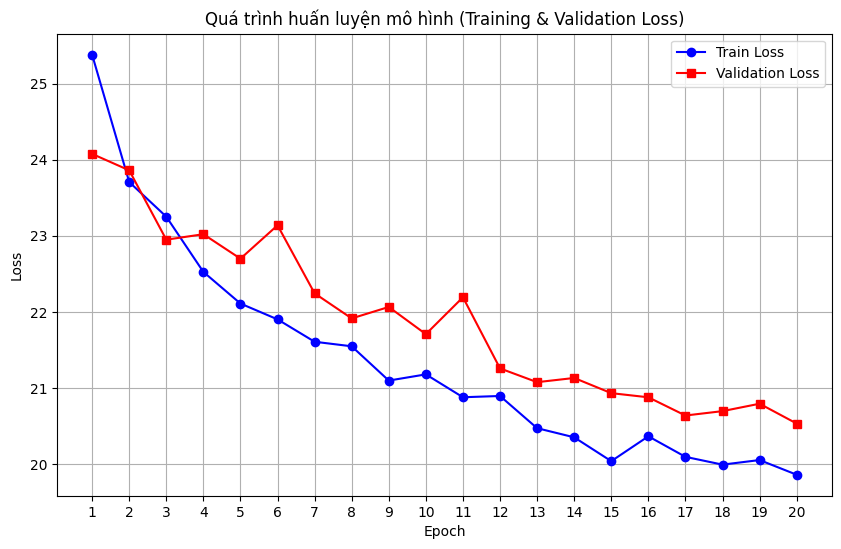

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss', color='red', marker='s')

plt.title('Quá trình huấn luyện mô hình (Training & Validation Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, NUM_EPOCHS + 1)) # Hiển thị rõ từng số epoch từ 1 đến 10
plt.legend() # Hiển thị chú thích cho hai đường thẳng
plt.grid(True) # Thêm lưới vào đồ thị cho dễ nhìn

# Hiển thị đồ thị lên màn hình
plt.show()

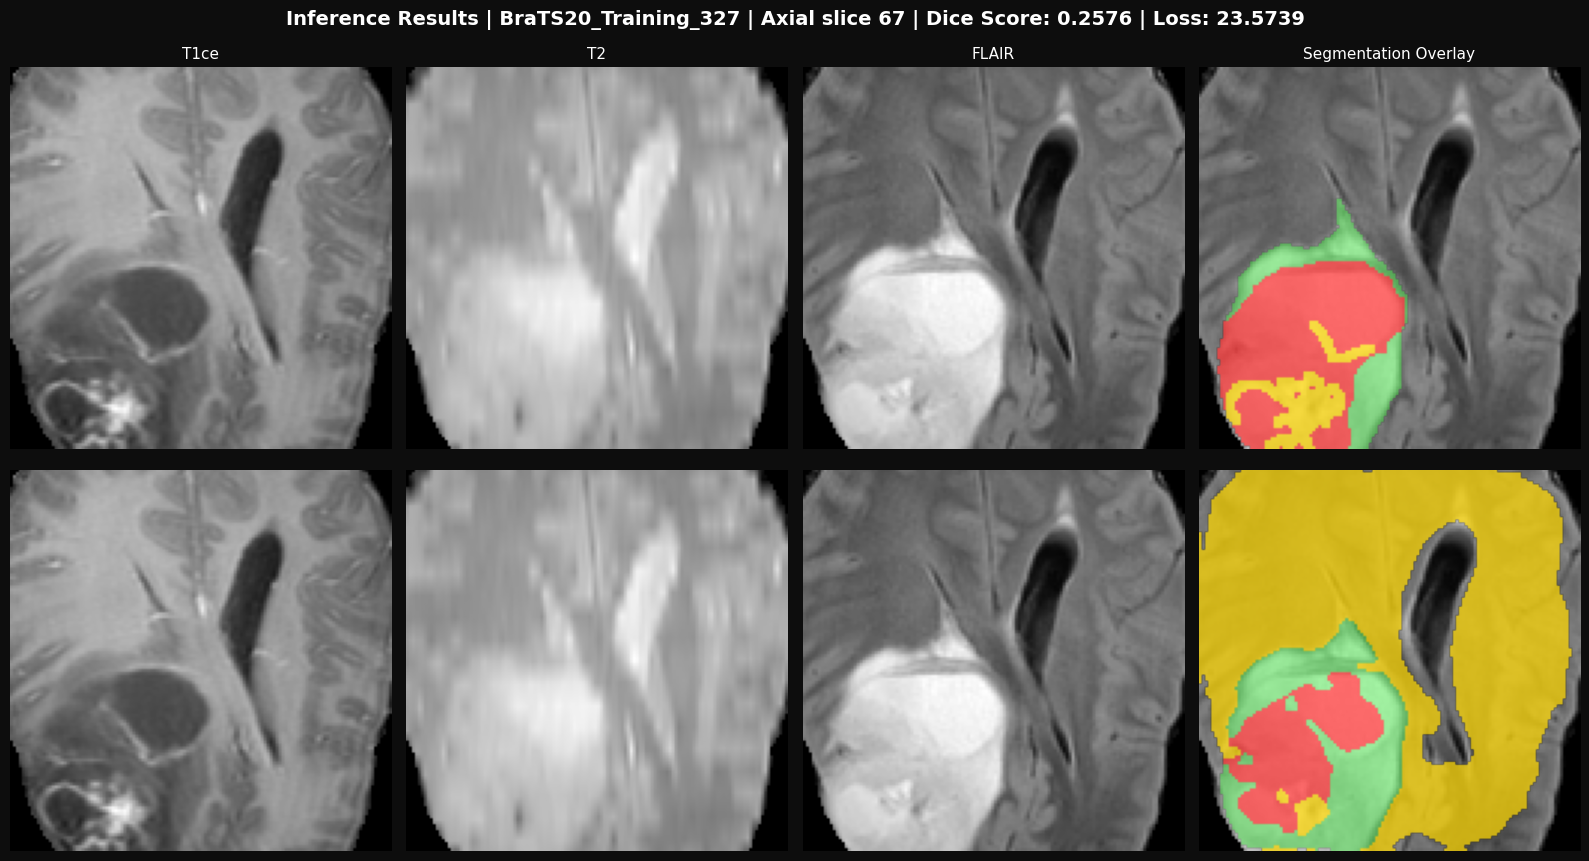

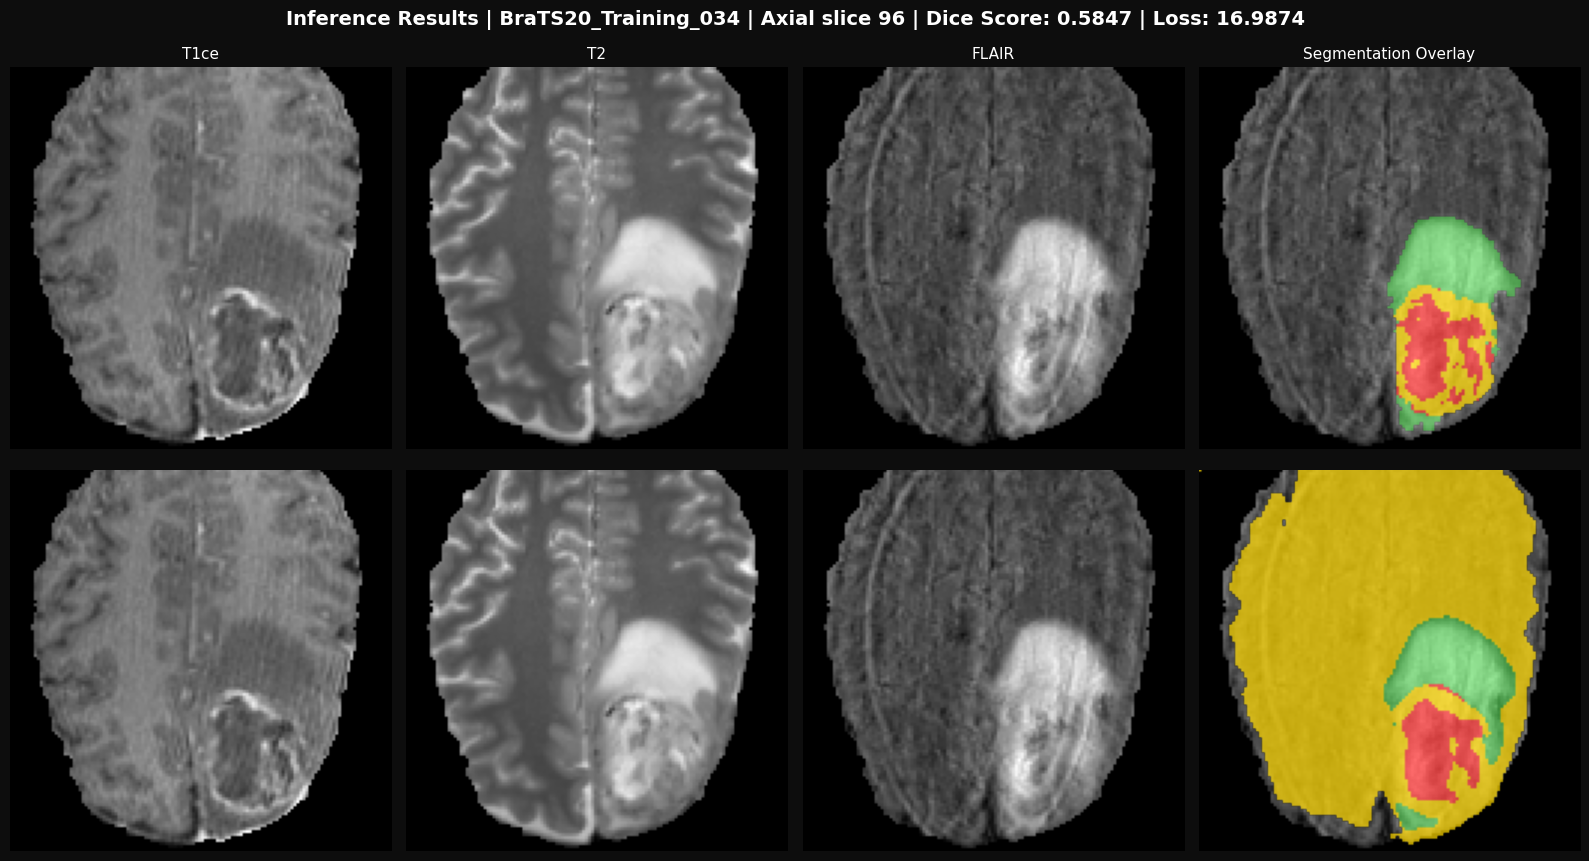

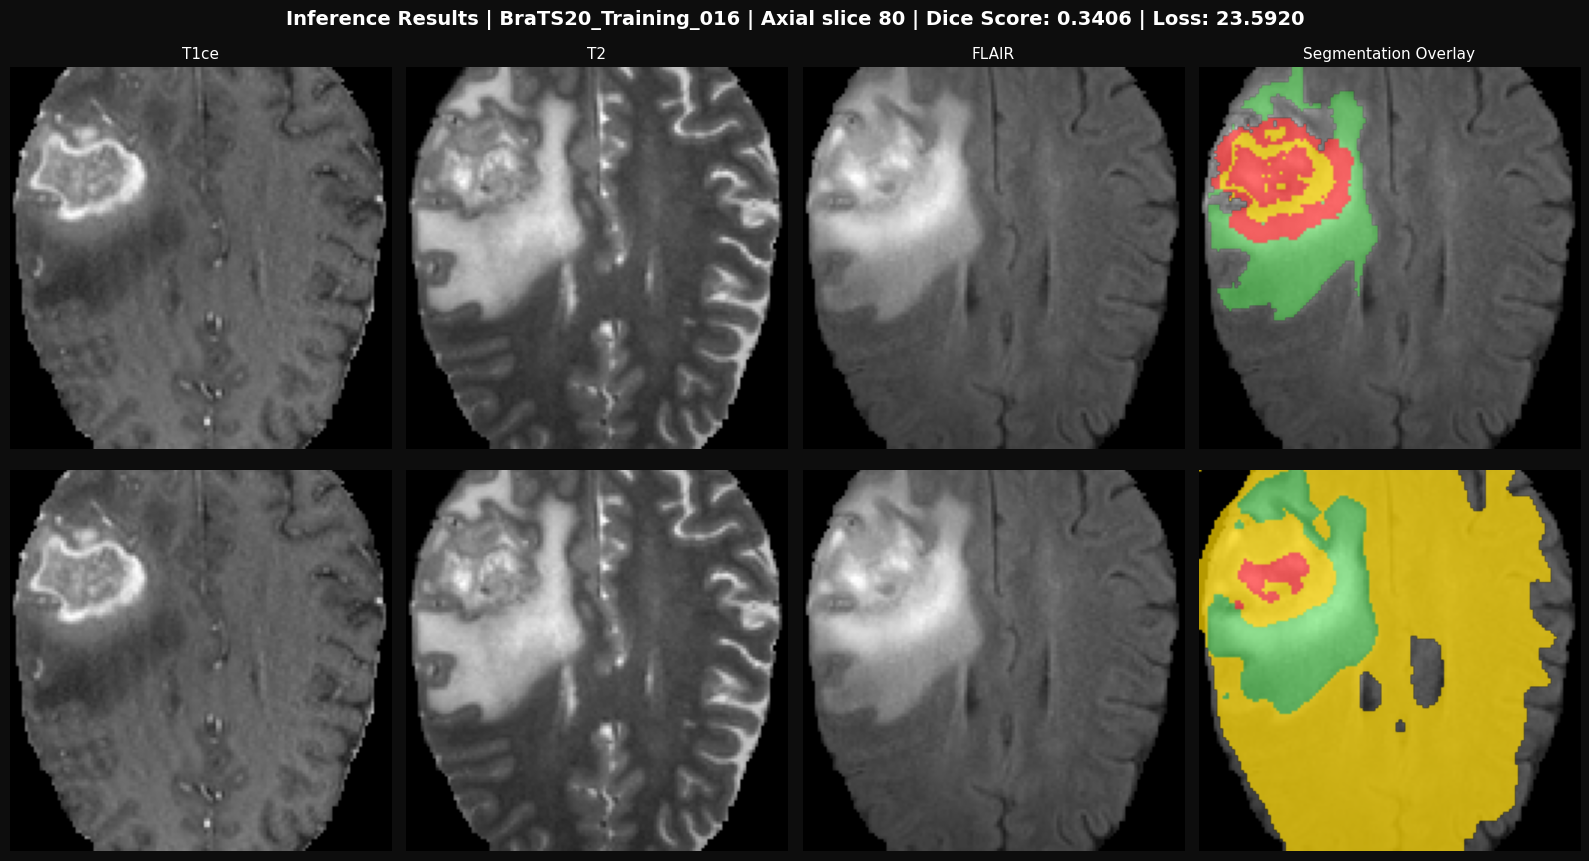

In [28]:
# Giữ nguyên cấu hình màu sắc BraTS đặc trưng của bạn
_COLOR_NCR = (1.0, 0.2,  0.2,  0.72)
_COLOR_ED  = (0.2, 0.9,  0.2,  0.45)
_COLOR_ET  = (1.0, 0.85, 0.0,  0.72)

# Map cho Ground Truth — dùng label BraTS gốc {0,1,2,4}
SEG_RGBA_GT = {1: _COLOR_NCR, 2: _COLOR_ED, 4: _COLOR_ET}

# Map cho Prediction — dùng channel index {0,1,2,3}
SEG_RGBA_PRED = {1: _COLOR_NCR, 2: _COLOR_ED, 3: _COLOR_ET}

def make_seg_rgba(seg_slice, rgba_map):
    rgba = np.zeros((*seg_slice.shape, 4), dtype=np.float32)
    for label, color in rgba_map.items():
        rgba[seg_slice == label] = color
    return rgba

def choose_tumor_slice(seg, is_gt=True):
    labels = [1, 2, 4] if is_gt else [1, 2, 3]
    tumor = np.isin(seg, labels)
    counts = tumor.sum(axis=(0, 1))
    if counts.max() == 0:
        return seg.shape[2] // 2
    return int(counts.argmax())

def calculate_dice_score(pred_np, true_np):
    """pred: {0,1,2,3} (channel index), true: {0,1,2,4} (BraTS labels)"""
    dice_per_class = []
    # Map từng channel pred → label GT tương ứng
    channel_to_gt = {1: 1, 2: 2, 3: 4}
    for pred_ch, gt_label in channel_to_gt.items():
        p_c = (pred_np == pred_ch)
        t_c = (true_np == gt_label)
        inter = np.sum(p_c & t_c)
        union = np.sum(p_c) + np.sum(t_c)
        if union == 0:
            dice_per_class.append(1.0)
        else:
            dice_per_class.append(2.0 * inter / union)
    return np.mean(dice_per_class)


def visualize_predictions_with_scores(model, dataloader, device, criterion=None, num_samples=3):
    """
    Hàm hiển thị kết quả dự đoán tái sử dụng giao diện ma trận ảnh chuyên nghiệp của BraTS.
    Hiển thị 2 hàng x 5 cột:
    - Hàng 1: Ground Truth (T1, T1ce, T2, FLAIR + True Mask Overlay)
    - Hàng 2: Model Prediction (T1, T1ce, T2, FLAIR + Predicted Mask Overlay)
    """
    model.eval()
    samples_visualized = 0
    
    # 1. Định nghĩa danh sách nhãn đầy đủ
    ALL_MODALITIES = ["T1ce", "T2", "FLAIR"]
    
    with torch.no_grad():
        for images, masks, patient_ids in dataloader:
            images_cuda = images.to(device)
            masks_cuda = masks.to(device)
            
            outputs = model(images_cuda)
            preds_cuda = torch.argmax(outputs, dim=1) 
            
            images_np = images.numpy()
            masks_np = masks.numpy()
            preds_np = preds_cuda.cpu().numpy()
            
            # 2. Lấy số lượng modalities thực tế từ hình dạng của tensor (C)
            num_modalities = images.size(1) # Lấy size của axis 1 (C)
            
            # Điều chỉnh nhãn hiển thị tương ứng với số kênh thực tế
            modalities_labels = ALL_MODALITIES[:num_modalities] if num_modalities <= 4 else [f"M{i}" for i in range(num_modalities)]
            
            for i in range(images.size(0)):
                if samples_visualized >= num_samples:
                    return
                
                patient_id = patient_ids[i]
                img_vol = images_np[i]   # (C, H, W, D)
                true_seg = masks_np[i]   # (H, W, D)
                pred_seg = preds_np[i]   # (H, W, D)
                
                # Tính toán Score (sử dụng pred_seg, true_seg dạng numpy như Cách 1 bài trước)
                dice_score = calculate_dice_score(pred_seg, true_seg)
                
                sample_loss_str = ""
                if criterion is not None:
                    sample_loss = criterion(outputs[i].unsqueeze(0), masks_cuda[i].unsqueeze(0))
                    sample_loss_str = f" | Loss: {sample_loss.item():.4f}"
                
                slice_idx = choose_tumor_slice(true_seg)
                
                # 3. Khởi tạo đồ thị với số cột = num_modalities + 1 (cột Overlay)
                num_columns = num_modalities + 1
                fig, axes = plt.subplots(2, num_columns, figsize=(4 * num_columns, 9))
                fig.patch.set_facecolor("#0d0d0d") 
                
                fig.suptitle(
                    f"Inference Results | {patient_id} | Axial slice {slice_idx} | Dice Score: {dice_score:.4f}{sample_loss_str}",
                    color="white", fontsize=14, fontweight="bold", y=0.98
                )
                
                row_labels = ["Ground Truth", "Model Prediction"]
                segs_data = [true_seg, pred_seg] 
                
                for r in range(2):
                    current_seg = segs_data[r]
                    
                    # Vẽ các cột ảnh MRI gốc dựa trên số lượng kênh thực tế
                    for c, modality_name in enumerate(modalities_labels):
                        ax = axes[r, c]
                        ax.imshow(img_vol[c, :, :, slice_idx].T, cmap="gray", origin="lower")
                        
                        if r == 0:
                            ax.set_title(modality_name, color="white", fontsize=11)
                        if c == 0:
                            ax.set_ylabel(row_labels[r], color="#cccccc", fontsize=12, fontweight="bold")
                        ax.axis("off")
                        ax.set_facecolor("black")
                    
                    # 4. Vẽ cột cuối cùng: Overlay nhãn màu lên kênh cuối cùng sẵn có (thường là FLAIR hoặc T2)
                    ax_overlay = axes[r, num_columns - 1]
                    # Sử dụng index [num_modalities - 1] để lấy kênh cuối cùng làm nền thay vì fix cứng index 3
                    ax_overlay.imshow(img_vol[num_modalities - 1, :, :, slice_idx].T, cmap="gray", origin="lower") 
                    rgba_map = SEG_RGBA_GT if r == 0 else SEG_RGBA_PRED
                    ax_overlay.imshow(make_seg_rgba(current_seg[:, :, slice_idx].T, rgba_map), origin="lower")
                    
                    if r == 0:
                        ax_overlay.set_title("Segmentation Overlay", color="white", fontsize=11)
                    ax_overlay.axis("off")
                    ax_overlay.set_facecolor("black")
                
                plt.tight_layout()
                plt.show()
                plt.close()
                
                samples_visualized += 1

# --- CÁCH CHẠY HÀM ---
visualize_predictions_with_scores(model, val_loader, device, criterion=criterion, num_samples=3)

In [29]:
def inference(model, dataloader, device):
    model.eval()
    all_preds = []
    all_masks = []
    all_patient_ids = []

    with torch.no_grad():
        for images, masks, patient_ids in tqdm(dataloader, desc="Inference"):
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()  # {0,1,2,3}

            # Remap channel 3 → label 4 to align with BraTS convention
            preds_brats = preds.copy()
            preds_brats[preds == 3] = 4  # {0,1,2,4}

            all_preds.append(preds_brats)
            all_masks.append(masks.cpu().numpy())
            all_patient_ids.extend(patient_ids)

    return np.concatenate(all_preds), np.concatenate(all_masks), all_patient_ids
# Run inference on validation set
predictions, true_masks, patient_ids = inference(model, val_loader, device)
print(f"Predictions shape: {predictions.shape}")
print(f"True masks shape: {true_masks.shape}")
print(f"Patient IDs: {patient_ids[:5]}")

Inference: 100%|██████████| 74/74 [00:22<00:00,  3.30it/s]


Predictions shape: (74, 128, 128, 128)
True masks shape: (74, 128, 128, 128)
Patient IDs: ['BraTS20_Training_327', 'BraTS20_Training_034', 'BraTS20_Training_016', 'BraTS20_Training_346', 'BraTS20_Training_058']


In [30]:
def predict_brats_case(model, folder_path, case_id, device, output_dir="./results"):
    model.eval()

    # Paper dùng T1ce, T2, FLAIR — KHÔNG có T1 (Section 4.1)
    modalities = ['_t1ce.nii', '_t2.nii', '_flair.nii']
    volume_list = []
    affine = None
    original_shape = None

    for mod in modalities:
        file_path = os.path.join(folder_path, f"{case_id}{mod}")
        if not os.path.exists(file_path):
            file_path += ".gz"
        nii_img = nib.load(file_path)
        if affine is None:
            affine = nii_img.affine
            original_shape = nii_img.shape
        img_data = nii_img.get_fdata()

        # Dùng Min-Max [0,1] — đúng với BraTSDataset3D (Section 4.1 paper)
        vmin, vmax = img_data.min(), img_data.max()
        if vmax > vmin:
            img_data = (img_data - vmin) / (vmax - vmin)
        else:
            img_data = np.zeros_like(img_data)
        volume_list.append(img_data)

    # Stack → crop 128³ centered (giống preprocessing trong dataset)
    image_data = np.stack(volume_list, axis=0)  # (3, H, W, D)
    # Crop center 128x128x128
    current_shape = image_data.shape[1:]  # (D, H, W)
    zoom_factors = tuple(128 / c for c in current_shape)
    image_data = np.stack([
        nd_zoom(image_data[c], zoom_factors, order=1)
        for c in range(image_data.shape[0])
    ], axis=0)

    image_tensor = torch.from_numpy(image_data).float().unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)          # (1, 4, 128, 128, 128) — no extra upsample
        preds = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy()  # (128,128,128), values {0,1,2,3}

    # Map channel 3 → label 4 để lưu theo convention BraTS
    preds_brats = preds.copy()
    preds_brats[preds == 3] = 4

    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"pred_{case_id}.nii")
    # Tạo volume full size, paste kết quả vào crop region
    zoom_back = tuple(c / 128 for c in original_shape)
    full_pred = nd_zoom(preds_brats.astype(np.float32), zoom_back, order=0).astype(np.uint8)
    nib.save(nib.Nifti1Image(full_pred, affine), output_path)

    print(f"Saved: {output_path}")
    return preds  # trả về {0,1,2,3} cho visualize

In [31]:
def visualize_single_prediction(folder_path, case_id, pred_mask, true_mask_path=None):
    """
    Hàm hiển thị kết quả dự đoán cho một ca bệnh đơn lẻ từ đường dẫn file .nii.
    
    Args:
        folder_path (str): Thư mục chứa ca bệnh (để load lại các ảnh MRI gốc).
        case_id (str): Tên ca bệnh.
        pred_mask (np.ndarray): Mảng mask dự đoán dạng NumPy (H, W, D) thu được từ mô hình.
        true_mask_path (str, optional): Đường dẫn tới file nhãn thật nếu có (ví dụ file _seg.nii).
                                       Nếu không truyền, hàm chỉ vẽ phần ảnh gốc và kết quả mô hình tìm được.
    """
    MODALITIES_LABELS = ["T1", "T1ce", "T2", "FLAIR"]
    modalities = ['_t1.nii', '_t1ce.nii', '_t2.nii', '_flair.nii']
    volume_list = []
    
    # 1. Load lại ảnh gốc (dùng để hiển thị làm nền)
    for mod in modalities:
        file_path = os.path.join(folder_path, f"{case_id}{mod}")
        if not os.path.exists(file_path):
            file_path += ".gz"
        nii_img = nib.load(file_path)
        volume_list.append(nii_img.get_fdata())
    
    img_vol = np.stack(volume_list, axis=0) # Shape: (4, H, W, D)
    
    # 2. Kiểm tra xem có nhãn Ground Truth (True Mask) để so sánh hay không
    has_true_mask = False
    true_seg = None
    dice_score_str = ""
    
    if true_mask_path and os.path.exists(true_mask_path):
        true_seg = nib.load(true_mask_path).get_fdata() # (H, W, D)
        has_true_mask = True
        
        # Tính toán nhanh Dice Score (NumPy version)
        _pred_to_gt = {1: 1, 2: 2, 3: 4}
        dice_list = []
        for pred_ch, gt_label in _pred_to_gt.items():
            p_c = (pred_mask == pred_ch)
            t_c = (true_seg == gt_label)
            intersection = np.sum(p_c & t_c)
            union = np.sum(p_c) + np.sum(t_c)
            if union > 0:
                dice_list.append((2.0 * intersection) / union)
        if dice_list:
            dice_score_str = f" | Dice Score: {np.mean(dice_list):.4f}"
            
    # Tự động chọn lát cắt chứa nhiều u nhất (ưu tiên tìm trên true mask, nếu không có thì tìm trên pred mask)
    if has_true_mask:
        slice_idx = choose_tumor_slice(true_seg, is_gt=True)
    else:
        slice_idx = choose_tumor_slice(pred_mask, is_gt=False)
    
    # 3. ĐIỀU CHỈNH SỐ HÀNG ĐỒ THỊ (2 hàng nếu có nhãn thật, 1 hàng nếu chỉ có dự đoán)
    num_rows = 2 if has_true_mask else 1
    fig, axes = plt.subplots(num_rows, 5, figsize=(22, 5 * num_rows))
    fig.patch.set_facecolor("#0d0d0d")
    
    # Đảm bảo axes luôn là mảng 2 chiều kể cả khi chỉ có 1 hàng để tránh lỗi chỉ mục
    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)
        
    fig.suptitle(
        f"Single Case Evaluation | {case_id} | Axial slice {slice_idx}{dice_score_str}",
        color="white", fontsize=14, fontweight="bold", y=0.98
    )
    
    row_labels = ["Ground Truth", "Model Prediction"] if has_true_mask else ["Model Prediction"]
    segs_data = [true_seg, pred_mask] if has_true_mask else [pred_mask]
    
    for r in range(num_rows):
        current_seg = segs_data[r]
        
        # Vẽ 4 cột ảnh MRI gốc (T1, T1ce, T2, FLAIR)
        for c, modality_name in enumerate(MODALITIES_LABELS):
            ax = axes[r, c]
            ax.imshow(img_vol[c, :, :, slice_idx].T, cmap="gray", origin="lower")
            if r == 0:
                ax.set_title(modality_name, color="white", fontsize=11)
            if c == 0:
                ax.set_ylabel(row_labels[r], color="#cccccc", fontsize=12, fontweight="bold")
            ax.axis("off")
            ax.set_facecolor("black")
        
        # Vẽ cột thứ 5: Overlay nhãn màu lên ảnh xung FLAIR
        ax_overlay = axes[r, 4]
        flair_slice = img_vol[3, :, :, slice_idx].T   # shape (W, H) — rows=W, cols=H
        rgba_map = SEG_RGBA_GT if r == 0 else SEG_RGBA_PRED
        seg_slice = make_seg_rgba(current_seg[:, :, slice_idx].T, rgba_map)

        # flair_slice.shape = (rows, cols) = (W_orig, H_orig)
        rows, cols = flair_slice.shape
        ext = [0, cols, 0, rows]   # [x_min, x_max, y_min, y_max] = [0, H_orig, 0, W_orig]

        ax_overlay.imshow(flair_slice, cmap="gray", origin="lower", extent=ext)
        ax_overlay.imshow(seg_slice, origin="lower", extent=ext)
        if r == 0:
            ax_overlay.set_title("Segmentation Overlay", color="white", fontsize=11)
        ax_overlay.axis("off")
        ax_overlay.set_facecolor("black")
        
    plt.tight_layout()
    plt.show()
    plt.close()

Đang chạy dự đoán cho ca bệnh: BraTS20_Validation_001
Saved: ./results\pred_BraTS20_Validation_001.nii
Predicted mask shape: (128, 128, 128) | Unique values: [0 1 2 3]
Đang hiển thị kết quả dự đoán...


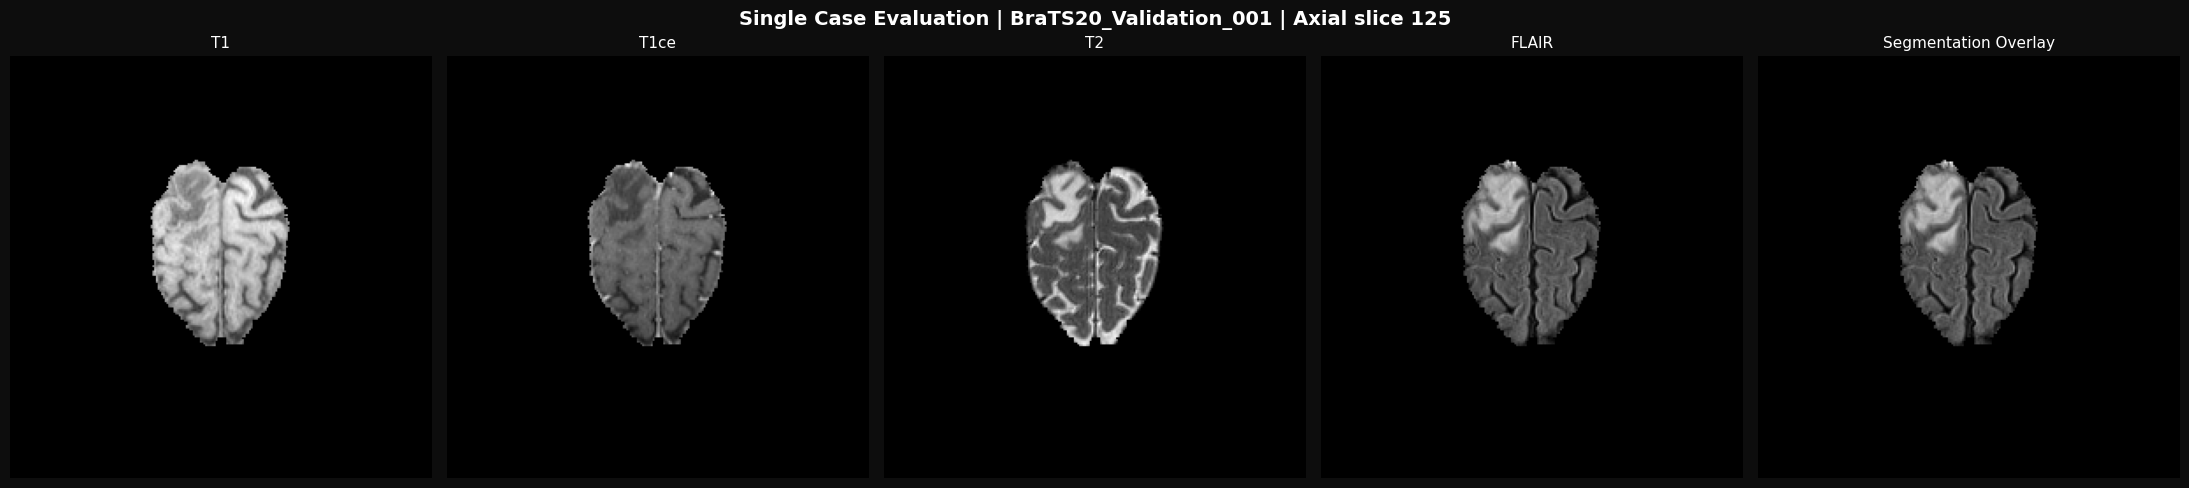

In [32]:
case_folder = "BraTS2020/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_001"
case_name = "BraTS20_Validation_001"
print(f"Đang chạy dự đoán cho ca bệnh: {case_name}")
pred_mask = predict_brats_case(model, case_folder, case_name, device, output_dir="./results")
print(f"Predicted mask shape: {pred_mask.shape} | Unique values: {np.unique(pred_mask)}")
print("Đang hiển thị kết quả dự đoán...")
visualize_single_prediction(
    folder_path=case_folder, 
    case_id=case_name, 
    pred_mask=pred_mask
)

In [33]:
import os
import numpy as np
import nibabel as nib
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import zoom as nd_zoom

# Bảng màu mẫu chuẩn cho mô hình đầu ra {1, 2, 3}
SEG_RGBA_PRED = {
    1: [1, 0, 0, 0.6],       # WT / NCR (Đỏ)
    2: [0, 1, 0, 0.6],       # ED (Xanh lá)
    3: [0, 0, 1, 0.6]        # ET (Xanh dương)
}

def choose_tumor_slice(mask):
    """Tìm axial slice chứa nhiều pixel u nhất để hiển thị"""
    tumor_mask = (mask > 0)
    slice_sums = np.sum(tumor_mask, axis=(0, 1)) # Sum trên trục H và W
    max_slice = np.argmax(slice_sums)
    if slice_sums[max_slice] == 0:
        return mask.shape[2] // 2 # Nếu không có u, lấy lát cắt chính giữa
    return max_slice

def make_seg_rgba(seg_slice, rgba_map):
    """Chuyển đổi mask sang ảnh RGBA màu, đảm bảo nền luôn trong suốt"""
    h, w = seg_slice.shape
    rgba_img = np.zeros((h, w, 4), dtype=np.float32)
    
    # Chỉ duyệt qua các nhãn thực sự có u (bỏ qua nhãn 0)
    for label, color in rgba_map.items():
        if label == 0:
            continue
        mask = (seg_slice == label)
        rgba_img[mask] = color
        
    return rgba_img

# --- HÀM KHÔI PHỤC KÍCH THƯỚC (INVERSE CROP/PAD) ---
def inverse_crop_or_pad_3d(pred_volume, resampled_shape):
    """
    Đưa volume dự đoán (128, 128, 128) về lại chính xác kích thước resampled_shape.
    Đảm bảo vị trí paste trùng khớp hoàn toàn với vị trí đã crop lúc tiền xử lý.
    """
    target_shape = pred_volume.shape # (128, 128, 128)
    new_volume = np.zeros(resampled_shape, dtype=pred_volume.dtype)
    
    slices_src = []
    slices_dst = []
    
    for c, t in zip(resampled_shape, target_shape):
        if c >= t:
            # Lúc trước: cắt từ start_c đến start_c + t
            # Bây giờ: paste ngược lại đúng vị trí đó trên ảnh resampled
            start_c = (c - t) // 2
            slices_src.append(slice(0, t))
            slices_dst.append(slice(start_c, start_c + t))
        else:
            # Lúc trước: ảnh gốc nhỏ hơn target, được pad vào giữa [start_t : start_t + c]
            # Bây giờ: lấy phần lõi từ ảnh 128^3 và paste phủ kín toàn bộ ảnh resampled
            start_t = (t - c) // 2
            slices_src.append(slice(start_t, start_t + c))
            slices_dst.append(slice(0, c))
            
    new_volume[tuple(slices_dst)] = pred_volume[tuple(slices_src)]
    return new_volume

In [34]:
def predict_brats_case_v2(model, folder_path, case_id, device, output_dir="./results"):
    model.eval()
    
    # Paper dùng T1ce, T2, FLAIR (Không dùng T1)
    modalities = ['_t1ce.nii', '_t2.nii', '_flair.nii']
    volume_list = []
    
    # Đọc file đầu tiên để lấy thông tin hình học gốc
    first_mod_path = os.path.join(folder_path, f"{case_id}_flair.nii")
    if not os.path.exists(first_mod_path): first_mod_path += ".gz"
    
    nii_img = nib.load(first_mod_path)
    original_affine = nii_img.affine
    original_shape = nii_img.shape
    original_spacing = nii_img.header.get_zooms()[:3]
    
    # 1. Pipeline Tiền xử lý dữ liệu giống lúc Train
    for mod in modalities:
        file_path = os.path.join(folder_path, f"{case_id}{mod}")
        if not os.path.exists(file_path): file_path += ".gz"
        
        img_data = nib.load(file_path).get_fdata(dtype=np.float32)
        
        # Bước A: Resample về target spacing (1,1,1)
        img_resampled = resample_volume(img_data, original_spacing, target_spacing=(1,1,1), order=1)
        resampled_shape = img_resampled.shape # Lưu lại shape này để tí nữa un-crop
        
        # Bước B: Crop hoặc Pad về 128x128x128
        img_cropped = crop_or_pad_3d(img_resampled, target_shape=(128, 128, 128))
        
        # Bước C: Chuẩn hóa Min-Max [0, 1] cho mỗi modality
        vmin, vmax = img_cropped.min(), img_cropped.max()
        if vmax > vmin:
            img_cropped = (img_cropped - vmin) / (vmax - vmin)
        else:
            img_cropped = np.zeros_like(img_cropped)
            
        volume_list.append(img_cropped)
        
    # Stack thành tensor (3, 128, 128, 128)
    image_tensor = torch.from_numpy(np.stack(volume_list, axis=0)).float().unsqueeze(0).to(device)
    
    # 2. Forward qua mô hình
    with torch.no_grad():
        outputs = model(image_tensor) # (1, 4, 128, 128, 128)
        preds = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy() # (128, 128, 128), values: {0,1,2,3}
        
    # 3. Pipeline Hậu xử lý ngược (Post-processing)
    # Bước A: Đưa từ 128^3 về kích thước sau resample 
    preds_un_cropped = inverse_crop_or_pad_3d(preds, resampled_shape)
    
    # Bước B: Resample ngược từ (1,1,1) về Spacing gốc của bệnh nhân (Dùng order=0 cho label)
    full_size_preds = resample_volume(preds_un_cropped.astype(np.float32), 
                                      original_spacing=(1,1,1), 
                                      target_spacing=original_spacing, 
                                      order=0).astype(np.uint8)
    
    # 4. Map channel 3 -> nhãn 4 để lưu đúng chuẩn BraTS convention
    preds_brats = full_size_preds.copy()
    preds_brats[full_size_preds == 3] = 4
    
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"pred_{case_id}.nii")
    nib.save(nib.Nifti1Image(preds_brats, original_affine), output_path)
    print(f"🎉 Đã lưu file dự đoán gốc tại: {output_path}")
    
    return full_size_preds # Trả về mask dạng {0,1,2,3} kích thước full gốc để hiển thị

In [35]:
def visualize_single_prediction_v2(folder_path, case_id, pred_mask, true_mask_path=None):
    MODALITIES_LABELS = ["T1", "T1ce", "T2", "FLAIR"]
    modalities = ['_t1.nii', '_t1ce.nii', '_t2.nii', '_flair.nii']
    volume_list = []
    
    # 1. Load các chuỗi xung gốc làm ảnh nền hiển thị
    for mod in modalities:
        file_path = os.path.join(folder_path, f"{case_id}{mod}")
        if not os.path.exists(file_path): file_path += ".gz"
        volume_list.append(nib.load(file_path).get_fdata(dtype=np.float32))
        
    img_vol = np.stack(volume_list, axis=0) # Shape: (4, H, W, D)
    
    # 2. Xử lý Ground Truth nếu có để tính Dice Score
    has_true_mask = False
    true_seg = None
    dice_score_str = ""
    
    if true_mask_path and os.path.exists(true_mask_path):
        true_seg = nib.load(true_mask_path).get_fdata(dtype=np.float32)
        has_true_mask = True
        
        # Tính Dice trung bình cho các phân vùng u
        _pred_to_gt = {1: 1, 2: 2, 3: 4}
        dice_list = []
        for pred_ch, gt_label in _pred_to_gt.items():
            p_c = (pred_mask == pred_ch)
            t_c = (true_seg == gt_label)
            intersection = np.sum(p_c & t_c)
            union = np.sum(p_c) + np.sum(t_c)
            if union > 0:
                dice_list.append((2.0 * intersection) / union)
        if dice_list:
            dice_score_str = f" | Avg Dice: {np.mean(dice_list):.4f}"
            
    # 3. Chọn tầng lát cắt (Axial Slice) tối ưu chứa u
    slice_idx = choose_tumor_slice(true_seg if has_true_mask else pred_mask)
    
    # 4. Vẽ đồ thị Matplotlib chỉn chu
    num_rows = 2 if has_true_mask else 1
    fig, axes = plt.subplots(num_rows, 5, figsize=(22, 4.5 * num_rows))
    fig.patch.set_facecolor("#111111")
    
    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)
        
    fig.suptitle(
        f"Evaluation Case: {case_id} | Axial Slice: {slice_idx}{dice_score_str}",
        color="white", fontsize=14, fontweight="bold", y=0.98
    )
    
    row_labels = ["Ground Truth", "Model Prediction"] if has_true_mask else ["Model Prediction"]
    segs_data = [true_seg, pred_mask] if has_true_mask else [pred_mask]
    
    for r in range(num_rows):
        current_seg = segs_data[r]
        
        # Vẽ 4 cột ảnh MRI nền dạng Grayscale
        for c, modality_name in enumerate(MODALITIES_LABELS):
            ax = axes[r, c]
            # .T (Transpose) để xoay đúng góc nhìn y tế thông thường
            ax.imshow(img_vol[c, :, :, slice_idx].T, cmap="gray", origin="lower")
            if r == 0:
                ax.set_title(modality_name, color="white", fontsize=12, fontweight="bold")
            if c == 0:
                ax.set_ylabel(row_labels[r], color="#ffffff", fontsize=12, fontweight="bold")
            ax.axis("off")
            
        # Vẽ cột số 5: Chồng chập lớp màu phân tách (Overlay) lên ảnh FLAIR gốc
        ax_overlay = axes[r, 4]
        flair_slice = img_vol[3, :, :, slice_idx].T
        
        # Lấy mask vùng u, xoay .T đồng bộ với ảnh gốc FLAIR
        seg_slice_2d = current_seg[:, :, slice_idx].T
        
        # Nếu là hàng Ground truth thì map nhãn {1, 2, 4}, hàng Pred thì map {1, 2, 3}
        if r == 0 and has_true_mask:
            # Map nhãn thực tế của BraTS dataset sang bảng màu
            rgba_map_gt = {0: [0,0,0,0.0], 1: [1,0,0,0.6], 2: [0,0,1,0.6], 4: [0,1,0,0.6]}
            seg_slice_rgba = make_seg_rgba(seg_slice_2d, rgba_map_gt)
        else:
            seg_slice_rgba = make_seg_rgba(seg_slice_2d, SEG_RGBA_PRED)
            
        # Vẽ đè khít khao nhờ kích cỡ đồng bộ tuyệt đối từ khâu post-processing
        ax_overlay.imshow(flair_slice, cmap="gray", origin="lower")
        ax_overlay.imshow(seg_slice_rgba, origin="lower")
        
        if r == 0:
            ax_overlay.set_title("Segmentation Overlay", color="white", fontsize=12, fontweight="bold")
        ax_overlay.axis("off")
        
    plt.tight_layout()
    plt.show()
    plt.close()

🚀 Bắt đầu thực hiện dự đoán: BraTS20_Validation_001
🎉 Đã lưu file dự đoán gốc tại: ./results\pred_BraTS20_Validation_001.nii
📊 Kích thước mask sau cùng: (240, 240, 155) | Nhãn tìm thấy: [0 1 2 3]
🎨 Đang kết xuất giao diện hiển thị...


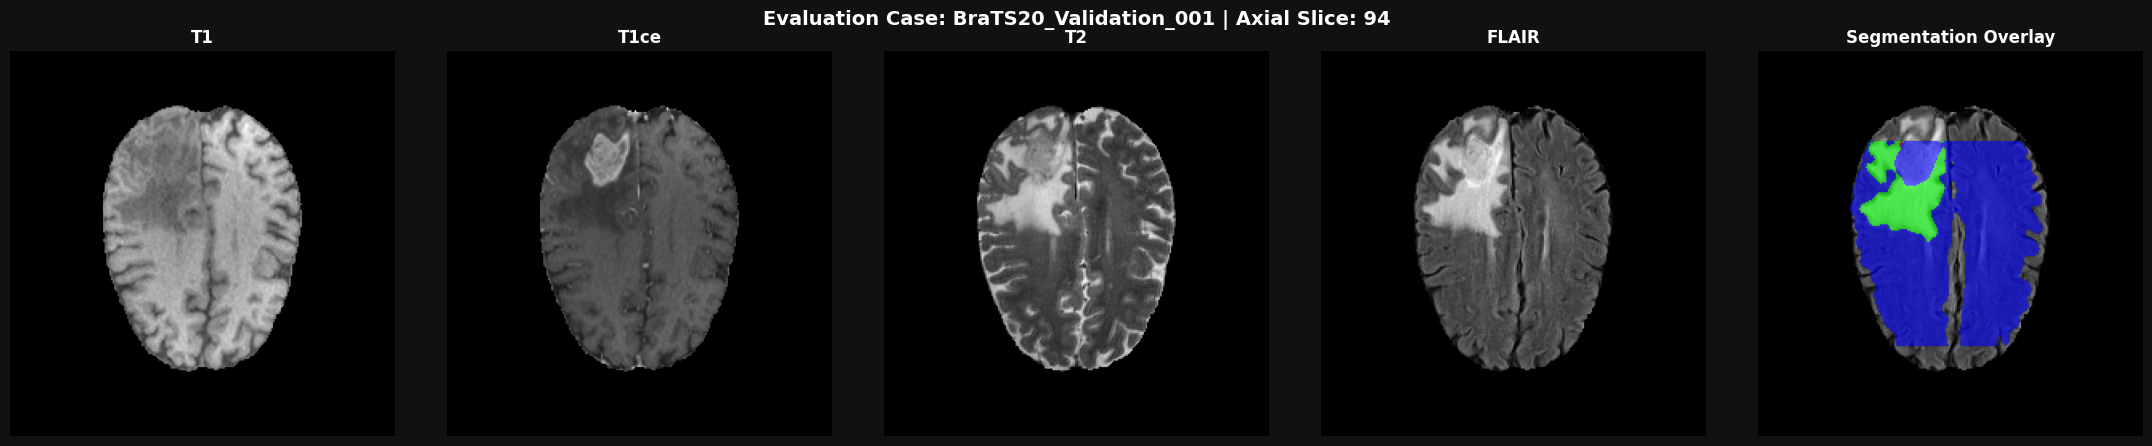

In [36]:
case_folder = "BraTS2020/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_001"
case_name = "BraTS20_Validation_001"

print(f"🚀 Bắt đầu thực hiện dự đoán: {case_name}")

# Chạy mô hình và tự động un-preprocess về kích thước gốc
pred_mask = predict_brats_case_v2(model, case_folder, case_name, device, output_dir="./results")

print(f"📊 Kích thước mask sau cùng: {pred_mask.shape} | Nhãn tìm thấy: {np.unique(pred_mask)}")
print("🎨 Đang kết xuất giao diện hiển thị...")

# Gọi hàm hiển thị trực quan
visualize_single_prediction_v2(
    folder_path=case_folder, 
    case_id=case_name, 
    pred_mask=pred_mask,
    true_mask_path=None # Nếu là tập Validation không có nhãn thật, để None. Nếu có file _seg.nii thì điền path vào đây.
)